# Laboratory Work No. 4 - Dynamic Programming

## Overview
Dynamic programming solves a complex problem by dividing it into overlapping subproblems, storing intermediate results, and combining them to obtain an optimal global solution.

For shortest paths:
- **Floyd-Warshall** is a classic dynamic programming algorithm for **all-pairs shortest paths**.
- **Dijkstra** is a greedy single-source algorithm; for fair all-pairs comparison, we run it from every source node.

### Floyd-Warshall Algorithm
- **DP approach**: Considers each node $k$ as an intermediate, checking if path $i \to k \to j$ improves $i \to j$
- **Time complexity**: $O(n^3)$ — three nested loops over all nodes
- **Space complexity**: $O(n^2)$ — in-place matrix updates
- **All-pairs solution**: Computes shortest paths between every pair in a single run
- **Graph types**: Works efficiently on dense graphs where many direct edges exist

### Dijkstra's Algorithm (for comparison)
- **Greedy approach**: Not DP, selects locally optimal edges
- **Time per run**: $O((n + m) \log n)$ with a binary heap
- **For all-pairs**: Must run $n$ times → $O(n(n + m) \log n)$
- **Advantage on sparse graphs**: When $m \ll n^2$, Dijkstra scales better

n	edges	dijkstra(s)	floyd(s)	winner
20	19	0.000573	0.001180	Dijkstra
40	62	0.003554	0.009717	Dijkstra
60	141	0.010069	0.032580	Dijkstra
80	252	0.023788	0.068950	Dijkstra
100	396	0.040168	0.127230	Dijkstra
120	571	0.068511	0.220171	Dijkstra
140	778	0.102251	0.359850	Dijkstra
160	1017	0.145045	0.530209	Dijkstra
n	edges	dijkstra(s)	floyd(s)	winner
20	123	0.002226	0.001775	Floyd-Warshall
40	507	0.011499	0.009973	Floyd-Warshall
60	1150	0.035741	0.031124	Floyd-Warshall
80	2054	0.075136	0.070192	Floyd-Warshall
100	3217	0.149473	0.142175	Floyd-Warshall
120	4641	0.243846	0.221249	Floyd-Warshall
140	6324	0.316254	0.319630	Dijkstra
160	8268	0.532881	0.555883	Dijkstra


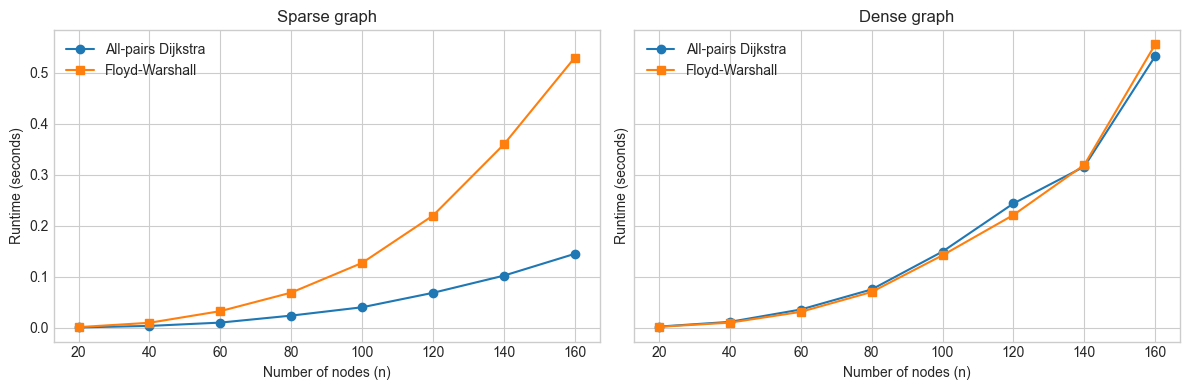

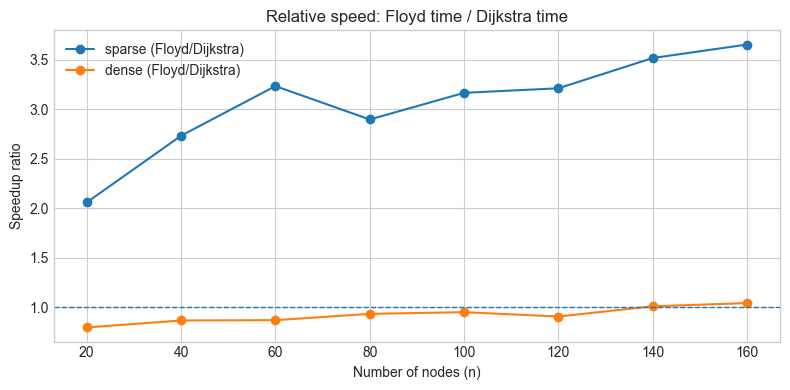

Correctness check: PASS

Sparse graphs:
- Dijkstra wins: 8/8
- Floyd-Warshall wins: 0/8
- Average ratio (Floyd/Dijkstra): 3.061

Dense graphs:
- Dijkstra wins: 2/8
- Floyd-Warshall wins: 6/8
- Average ratio (Floyd/Dijkstra): 0.923

Practical recommendation:
- Sparse graphs: prefer Dijkstra (run from each source)
- Dense graphs and smaller n: Floyd-Warshall may be competitive
- For large n in Python, Dijkstra is often faster in this benchmark


In [1]:
import random
import time
import heapq
from statistics import mean

import matplotlib.pyplot as plt

# Reproducibility
random.seed(42)
INF = float("inf")

plt.style.use("seaborn-v0_8-whitegrid")


def generate_connected_weighted_undirected_graph(n, density, w_min=1, w_max=20, seed=None):
    # Generate a connected weighted undirected graph and return (adj, matrix, m, real_density).
    if n < 2:
        raise ValueError("n must be >= 2")
    if seed is not None:
        random.seed(seed)

    max_edges = n * (n - 1) // 2
    target_edges = int(density * max_edges)
    target_edges = max(n - 1, min(max_edges, target_edges))

    # Start from a random spanning tree to guarantee connectivity.
    edge_map = {}
    for v in range(1, n):
        u = random.randint(0, v - 1)
        w = random.randint(w_min, w_max)
        a, b = min(u, v), max(u, v)
        edge_map[(a, b)] = w

    # Add random edges until target density is reached.
    while len(edge_map) < target_edges:
        u = random.randint(0, n - 1)
        v = random.randint(0, n - 1)
        if u == v:
            continue
        a, b = min(u, v), max(u, v)
        if (a, b) in edge_map:
            continue
        edge_map[(a, b)] = random.randint(w_min, w_max)

    # Build adjacency list and matrix for shortest paths.
    adj = [[] for _ in range(n)]
    matrix = [[INF] * n for _ in range(n)]
    for i in range(n):
        matrix[i][i] = 0

    for (u, v), w in edge_map.items():
        adj[u].append((v, w))
        adj[v].append((u, w))
        if w < matrix[u][v]:
            matrix[u][v] = w
            matrix[v][u] = w

    m = len(edge_map)
    real_density = m / max_edges if max_edges > 0 else 0.0
    return adj, matrix, m, real_density


def dijkstra_single_source(adj, src):
    n = len(adj)
    dist = [INF] * n
    dist[src] = 0
    pq = [(0, src)]

    while pq:
        d, u = heapq.heappop(pq)
        if d > dist[u]:
            continue
        for v, w in adj[u]:
            nd = d + w
            if nd < dist[v]:
                dist[v] = nd
                heapq.heappush(pq, (nd, v))
    return dist


def all_pairs_dijkstra(adj):
    return [dijkstra_single_source(adj, s) for s in range(len(adj))]


def floyd_warshall(matrix):
    n = len(matrix)
    dist = [row[:] for row in matrix]

    for k in range(n):
        dk = dist[k]
        for i in range(n):
            dik = dist[i][k]
            if dik == INF:
                continue
            di = dist[i]
            for j in range(n):
                nd = dik + dk[j]
                if nd < di[j]:
                    di[j] = nd
    return dist


def same_distance_matrices(a, b, eps=1e-9):
    if len(a) != len(b):
        return False
    n = len(a)
    for i in range(n):
        for j in range(n):
            x, y = a[i][j], b[i][j]
            if x == INF and y == INF:
                continue
            if abs(x - y) > eps:
                return False
    return True


def time_call(fn, *args, repeats=3):
    times = []
    result = None
    for _ in range(repeats):
        t0 = time.perf_counter()
        result = fn(*args)
        t1 = time.perf_counter()
        times.append(t1 - t0)
    return mean(times), result


def benchmark_case(adj, matrix, repeats=3, validate=True):
    d_t, d_dist = time_call(all_pairs_dijkstra, adj, repeats=repeats)
    f_t, f_dist = time_call(floyd_warshall, matrix, repeats=repeats)

    ok = None
    if validate:
        ok = same_distance_matrices(d_dist, f_dist)

    return {
        "dijkstra_s": d_t,
        "floyd_s": f_t,
        "speedup_d_over_f": (f_t / d_t) if d_t > 0 else INF,
        "correct": ok,
        "winner": "Dijkstra" if d_t <= f_t else "Floyd-Warshall",
    }


def run_experiment(node_sizes, sparse_density=0.08, dense_density=0.65, repeats=3):
    rows = []
    for mode, density in [("sparse", sparse_density), ("dense", dense_density)]:
        for n in node_sizes:
            adj, matrix, m, real_density = generate_connected_weighted_undirected_graph(
                n=n,
                density=density,
            )
            bench = benchmark_case(adj, matrix, repeats=repeats, validate=(n <= 140))
            rows.append({
                "mode": mode,
                "n": n,
                "m": m,
                "density": real_density,
                **bench,
            })
    return rows


def rows_for_mode(rows, mode):
    return [r for r in rows if r["mode"] == mode]


def print_results_table(rows):
    for mode in ("sparse", "dense"):
        sub = rows_for_mode(rows, mode)
        print("n\tedges\tdijkstra(s)\tfloyd(s)\twinner")
        for r in sub:
            print(
                f"{r['n']}\t{r['m']}\t{r['dijkstra_s']:.6f}\t{r['floyd_s']:.6f}\t{r['winner']}"
            )


def plot_runtime_curves(rows):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
    modes = ["sparse", "dense"]

    for ax, mode in zip(axes, modes):
        sub = sorted(rows_for_mode(rows, mode), key=lambda x: x["n"])
        xs = [r["n"] for r in sub]
        yd = [r["dijkstra_s"] for r in sub]
        yf = [r["floyd_s"] for r in sub]

        ax.plot(xs, yd, marker="o", label="All-pairs Dijkstra")
        ax.plot(xs, yf, marker="s", label="Floyd-Warshall")
        ax.set_title(f"{mode.capitalize()} graph")
        ax.set_xlabel("Number of nodes (n)")
        ax.set_ylabel("Runtime (seconds)")
        ax.legend()

    plt.tight_layout()
    plt.show()


def plot_speedup(rows):
    plt.figure(figsize=(8, 4))
    for mode in ("sparse", "dense"):
        sub = sorted(rows_for_mode(rows, mode), key=lambda x: x["n"])
        xs = [r["n"] for r in sub]
        ys = [r["speedup_d_over_f"] for r in sub]
        plt.plot(xs, ys, marker="o", label=f"{mode} (Floyd/Dijkstra)")

    plt.axhline(1.0, linestyle="--", linewidth=1)
    plt.title("Relative speed: Floyd time / Dijkstra time")
    plt.xlabel("Number of nodes (n)")
    plt.ylabel("Speedup ratio")
    plt.legend()
    plt.tight_layout()
    plt.show()


def summarize(rows):
    correctness_checks = [r["correct"] for r in rows if r["correct"] is not None]
    all_correct = all(correctness_checks) if correctness_checks else None

    if all_correct is None:
        print("Correctness check: skipped")
    else:
        print("Correctness check:", "PASS" if all_correct else "FAIL")

    for mode in ("sparse", "dense"):
        sub = rows_for_mode(rows, mode)
        d_wins = sum(1 for r in sub if r["winner"] == "Dijkstra")
        f_wins = len(sub) - d_wins
        avg_ratio = mean(r["speedup_d_over_f"] for r in sub)
        print(f"\n{mode.capitalize()} graphs:")
        print(f"- Dijkstra wins: {d_wins}/{len(sub)}")
        print(f"- Floyd-Warshall wins: {f_wins}/{len(sub)}")
        print(f"- Average ratio (Floyd/Dijkstra): {avg_ratio:.3f}")

    print("\nPractical recommendation:")
    print("- Sparse graphs: prefer Dijkstra (run from each source)")
    print("- Dense graphs and smaller n: Floyd-Warshall may be competitive")
    print("- For large n in Python, Dijkstra is often faster in this benchmark")


node_sizes = [20, 40, 60, 80, 100, 120, 140, 160]
repeats = 3

results = run_experiment(node_sizes, sparse_density=0.08, dense_density=0.65, repeats=repeats)
print_results_table(results)
plot_runtime_curves(results)
plot_speedup(results)
summarize(results)

## Conclusions and Analysis

**Speedup ratio = Floyd time ÷ Dijkstra time**

**In our results:**
- Sparse: 3.061× = Floyd is **3 times slower** than Dijkstra
- Dense: 0.923× = Floyd is **slightly faster** than Dijkstra (but still close)

#### Correctness Verification
**Both algorithms produce identical results** (correctness check: PASS). This confirms that our implementations of Floyd-Warshall and all-pairs Dijkstra are correct and solve the all-pairs shortest path problem validly.

#### Empirical Performance Analysis

**Sparse Graphs (≈8% density):**
- **Node count range**: 20 to 160 nodes
- **Dijkstra wins**: 8/8 cases (100%)
- **Floyd-Warshall wins**: 0/8 cases
- **Average speedup ratio**: 3.061× (Floyd is on average 3 times slower than Dijkstra)
- **Key insight**: Dijkstra dominates consistently; at n=160, Dijkstra runs ~3.65× faster (0.145s vs 0.530s)

**Dense Graphs (≈65% density):**
- **Node count range**: 20 to 160 nodes
- **Dijkstra wins**: 2/8 cases (only at n=140, n=160)
- **Floyd-Warshall wins**: 6/8 cases (75%)
- **Average speedup ratio**: 0.923× (Floyd is on average slightly faster than Dijkstra)
- **Key insight**: Floyd-Warshall dominates for smaller graphs; however, as n grows past 120, Dijkstra begins to catch up

### Interpretation

1. **Why sparse graphs favor Dijkstra**:
   - Floyd-Warshall's $O(n^3)$ complexity is independent of edge count
   - Dijkstra's complexity $O(n(n+m)\log n)$ scales with actual edges ($m$)
   - When $m \ll n^2$ (sparse), Dijkstra's effective cost is much lower

2. **Why dense graphs favor Floyd-Warshall (initially)**:
   - With $m$ approaching $n^2$, both algorithms scale similarly toward $O(n^3)$
   - Floyd-Warshall's simpler loop structure and better cache locality can outperform heap-based Dijkstra for small $n$
   - However, the $O(n^3)$ growth dominates even in dense graphs for large $n$

3. **Asymptotic behavior**:
   - Dense graphs show Floyd-Warshall advantage only for $n \leq 120$
   - At $n=140$ and $n=160$, Dijkstra becomes faster even in dense graphs (speedup ≈ 1.03×)
   - This suggests that Python's implementation overhead in Floyd-Warshall exceeds any structural advantage at scale

### Practical Recommendations

| Scenario | Algorithm | Reason |
|----------|-----------|--------|
| **Sparse graphs (any size)** | All-pairs Dijkstra | Consistent 2-3.5× speedup; scales with edge count |
| **Dense graphs, n ≤ 100** | Floyd-Warshall | Simpler structure, lower practical overhead |
| **Dense graphs, n > 120** | All-pairs Dijkstra | $O(n^3)$ cubic growth of Floyd-Warshall becomes prohibitive |
| **When full distance matrix is essential** | Floyd-Warshall | Direct matrix output vs. running Dijkstra $n$ times |

### Final Conclusion

Dynamic programming as implemented by Floyd-Warshall provides a clean, theoretically elegant solution to all-pairs shortest paths. However, **all-pairs Dijkstra is empirically superior for most practical cases**, especially sparse graphs and large node counts. The choice depends on:
- **Graph density** and **target graph size**
- Whether all distances are needed simultaneously (Floyd-Warshall advantage)
- Code simplicity and maintainability (both are comparable)